# Backtest — final_signal vs lr_signal

**Signal hierarchy:**
- `final_signal` = GMM regime filter + MinHash confirmation (rule-based)
- `lr_signal` = logistic regression trained to predict final_signal from (spread, z_score, regime)

These are sequential layers, not alternatives. Comparing them shows whether the LR can recover the same decisions from raw features alone.

**Execution:** signal +1 => long asset A, signal -1 => short asset A. Asset B is ignored (spread proxy). Position entered at next bar open (1-bar lag).

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

SIGNAL_COLS = ['final_signal', 'lr_signal']
COLORS      = {'final_signal': '#2196F3', 'lr_signal': '#FF5722'}

In [19]:
filtered_residuals = pd.read_csv('../data/manipulated/pr_filtered_residuals.csv', index_col=0, parse_dates=True)

train_residuals = pd.read_csv("../data/manipulated/residuals_train.csv", index_col=0, parse_dates=True)
val_residuals = pd.read_csv("../data/manipulated/residuals_val.csv", index_col=0, parse_dates=True)
test_residuals = pd.read_csv("../data/manipulated/residuals_test.csv", index_col=0, parse_dates=True)

train_start = train_residuals.index.min()
train_end = train_residuals.index.max()

val_start = val_residuals.index.min()
val_end = val_residuals.index.max()

test_start = test_residuals.index.min()
test_end = test_residuals.index.max()

In [20]:
def compute_pair_pnl(signal: pd.Series, price_a: pd.Series) -> pd.Series:
    """
    Daily log-return PnL for asset A under a given signal.

      signal +1 => long A  => earn log(A_t / A_{t-1})
      signal -1 => short A => earn -log(A_t / A_{t-1})
      signal  0 => flat    => earn 0

    1-bar lag: signal seen at close of t, position taken at t+1.
    """
    log_ret_a = np.log(price_a / price_a.shift(1))
    position  = signal.shift(1).fillna(0)
    return (position * log_ret_a).rename(signal.name)

In [21]:
active_pairs = pd.read_csv('../data/manipulated/active_pairs.csv')

pair_pnl = {col: [] for col in SIGNAL_COLS}

for _, row in active_pairs.iterrows():
    a, b = row['asset_a'], row['asset_b']
    path = f'../data/manipulated/spreads/{a}_{b}.csv'
    try:
        df = pd.read_csv(path, index_col=0, parse_dates=True)
    except FileNotFoundError:
        continue

    missing = [c for c in SIGNAL_COLS if c not in df.columns]
    if missing:
        print(f'Skipping {a}/{b} — missing columns: {missing}')
        continue

    if a not in filtered_residuals.columns:
        print(f'Skipping {a}/{b} — {a} not in filtered_residuals')
        continue

    # test period only
    test_df = df.loc[val_start:val_end]
    price_a = filtered_residuals[a].loc[val_start:val_end]

    # align on shared index
    shared = test_df.index.intersection(price_a.index)
    if len(shared) < 10:
        continue

    price_a = price_a.loc[shared]

    for col in SIGNAL_COLS:
        signal = test_df[col].loc[shared]
        pnl    = compute_pair_pnl(signal, price_a)
        pair_pnl[col].append(pnl.rename(f'{a}_{b}'))

print(f'Pairs loaded: {len(pair_pnl[SIGNAL_COLS[0]])}')

/home/dilab/Documents/CSCI4022/pairs-trading-ml/venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/dilab/Documents/CSCI4022/pairs-trading-ml/venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/dilab/Documents/CSCI4022/pairs-trading-ml/venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/dilab/Documents/CSCI4022/pairs-trading-ml/venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/dilab/Documents/CSCI4022/pairs-trading-ml/venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value en

Pairs loaded: 140


/home/dilab/Documents/CSCI4022/pairs-trading-ml/venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/dilab/Documents/CSCI4022/pairs-trading-ml/venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/dilab/Documents/CSCI4022/pairs-trading-ml/venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/dilab/Documents/CSCI4022/pairs-trading-ml/venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/dilab/Documents/CSCI4022/pairs-trading-ml/venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value en

In [22]:
# Equal-weight portfolio: average log return across all pairs each day
portfolio = {}
for col in SIGNAL_COLS:
    all_series     = pd.concat(pair_pnl[col], axis=1).fillna(0)
    portfolio[col] = all_series.sum(axis=1) / all_series.shape[1]

portfolio_df = pd.DataFrame(portfolio)
cumulative   = portfolio_df.cumsum()

print('Portfolio daily log-return stats:')
print(portfolio_df.describe().round(6))

Portfolio daily log-return stats:
       final_signal   lr_signal
count    252.000000  252.000000
mean      -0.004048   -0.008260
std        0.038107    0.066319
min       -0.240689   -0.411094
25%       -0.010786   -0.017213
50%        0.000000    0.000000
75%        0.007266    0.016280
max        0.094776    0.162168


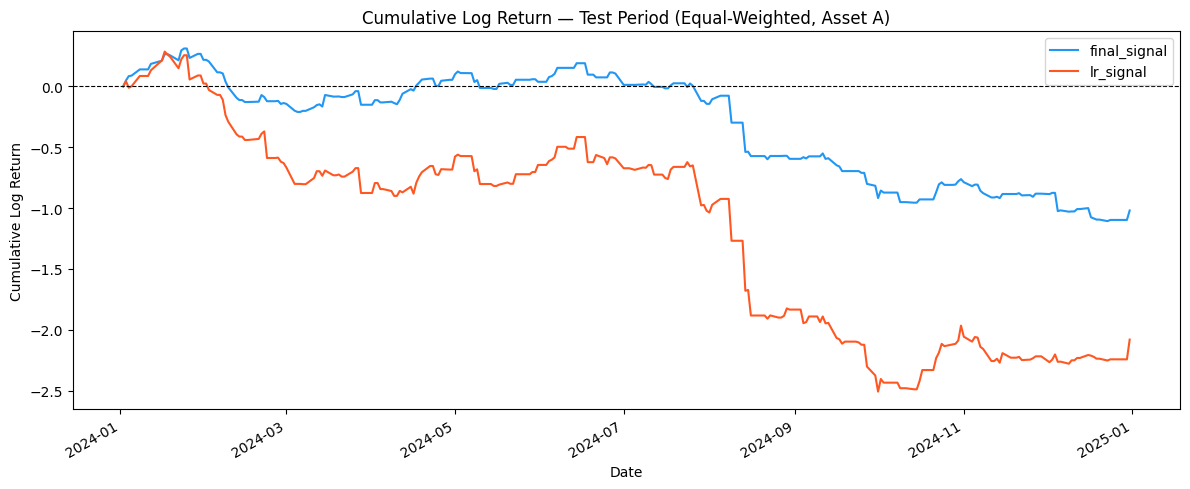

In [23]:
fig, ax = plt.subplots(figsize=(12, 5))
for col in SIGNAL_COLS:
    cumulative[col].plot(ax=ax, label=col, color=COLORS[col], linewidth=1.5)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Cumulative Log Return — Test Period (Equal-Weighted, Asset A)')
ax.set_ylabel('Cumulative Log Return')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.show()

In [24]:
def backtest_metrics(log_ret: pd.Series, periods_per_year=252) -> dict:
    total    = log_ret.sum()
    ann_ret  = log_ret.mean() * periods_per_year
    vol      = log_ret.std() * np.sqrt(periods_per_year)
    sharpe   = ann_ret / vol if vol > 0 else np.nan
    cum      = log_ret.cumsum()
    max_dd   = (cum - cum.cummax()).min()
    nonzero  = log_ret[log_ret != 0]
    hit_rate = (nonzero > 0).mean() if len(nonzero) else np.nan
    return {
        'Total log return': round(total, 4),
        'Ann. log return':  round(ann_ret, 4),
        'Ann. volatility':  round(vol, 4),
        'Sharpe ratio':     round(sharpe, 3),
        'Max drawdown':     round(max_dd, 4),
        'Hit rate':         round(hit_rate, 3),
        'Active days':      int((log_ret != 0).sum()),
    }

metrics = pd.DataFrame(
    {col: backtest_metrics(portfolio_df[col]) for col in SIGNAL_COLS}
)
print(metrics)

                  final_signal  lr_signal
Total log return       -1.0201    -2.0814
Ann. log return        -1.0201    -2.0814
Ann. volatility         0.6049     1.0528
Sharpe ratio           -1.6860    -1.9770
Max drawdown           -1.4189    -2.7948
Hit rate                0.5030     0.4800
Active days           161.0000   177.0000


In [25]:
# Per-pair total log return
final_totals = {s.name: s.sum() for s in pair_pnl['final_signal']}
lr_totals    = {s.name: s.sum() for s in pair_pnl['lr_signal']}

print(f'\n{"Pair":<20} {"final_signal":>14} {"lr_signal":>12}')
print('-' * 48)
for key in sorted(final_totals):
    print(f'{key:<20} {final_totals[key]:>14.4f} {lr_totals.get(key, float("nan")):>12.4f}')


Pair                   final_signal    lr_signal
------------------------------------------------
ACN_MSI                     -2.6582       6.2923
AMCR_ACN                    -1.3664      -4.8505
AMCR_ARES                   -0.0648      -2.6365
AMCR_CBRE                  -11.3941      -7.4239
AMCR_ECL                    -0.0168      -1.3268
AMCR_EL                     -4.5049      -7.1640
AMCR_GRMN                    2.8488       4.8331
AMCR_HAS                     0.9122      -2.6916
AMCR_IT                     -0.3155      -3.0851
AMCR_KKR                    -2.2664      -1.5595
AMCR_MSI                     2.9523      -3.6015
AMCR_NKE                    -1.6961      -4.8397
AMCR_PAYX                   -1.4040      -4.4380
APH_APO                     -4.4750     -11.7192
APH_ARES                    -0.6082     -11.2621
APH_BLK                     -1.5694      -0.2403
APH_CBRE                    -3.6130      -1.4609
APH_CRH                     -1.9100      -2.5695
APH_CSX            